In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import sklearn.datasets

In [2]:
def get_iris_df():
    ds = sklearn.datasets.load_iris()
    df = pd.DataFrame(ds['data'], columns=ds['feature_names'])
    code_species_map = dict(zip(range(3), ds['target_names']))
    df['species'] = [code_species_map[c] for c in ds['target']]
    return df

In [3]:
df = get_iris_df()
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
sums_by_species = df.groupby('species').sum()
var = 'sepal width (cm)'
sums_by_species[var].plot(kind='pie', fontsize=20)
plt.ylabel(var, horizontalalignment='left')
plt.title('Desglose por ' + var, fontsize=25)
plt.savefig('graficos_sectores_iris_una_variable.jpg')
plt.close()

Text(0.5, 1.0, 'Desglose por sepal width (cm)')

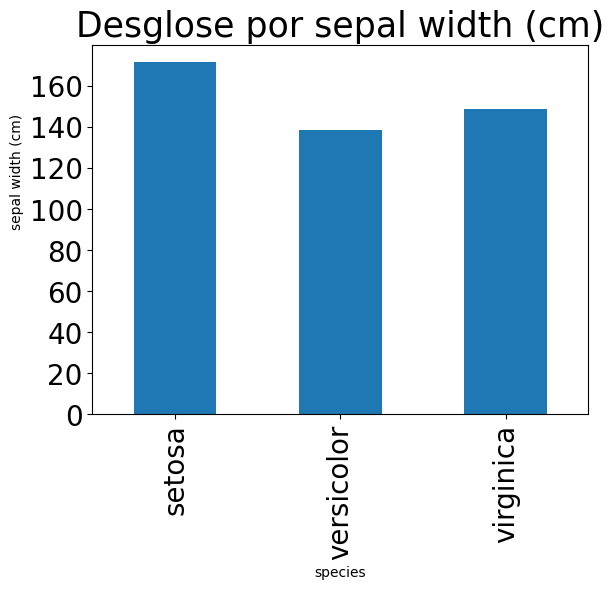

In [5]:
sums_by_species[var].plot(kind='bar', fontsize=20)
plt.ylabel(var, horizontalalignment='left')
plt.title('Desglose por ' + var, fontsize=25)

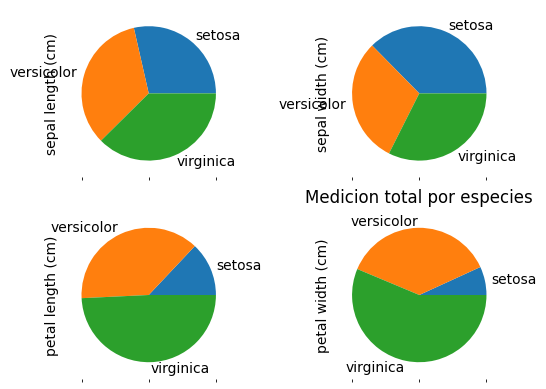

In [6]:
sum_by_species = df.groupby('species').sum()
sum_by_species.plot(kind='pie', subplots=True, layout=(2,2), legend=False)
plt.title('Medicion total por especies')
plt.show()

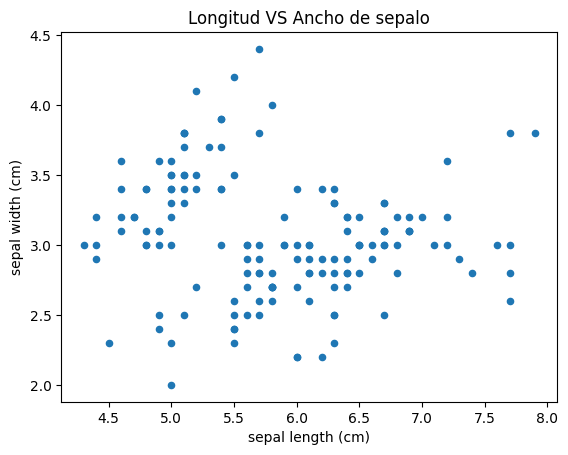

In [7]:
df.plot(kind='scatter', x = 'sepal length (cm)', y='sepal width (cm)')
plt.title('Longitud VS Ancho de sepalo')
plt.show()

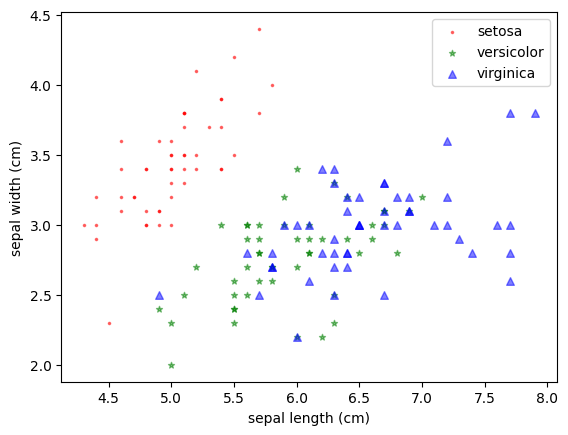

In [8]:
colors = ['r', 'g', 'b']
markers = ['.', '*', '^']
fig, ax = plt.subplots(1, 1)
for i, spec in enumerate(df['species'].unique()):
    ddf = df[df['species']==spec]
    ddf.plot(kind = 'scatter', x='sepal length (cm)', y='sepal width (cm)', 
             alpha=0.5, s=10*(i+1), ax=ax, color=colors[i], marker=markers[i], 
            label=spec)
plt.legend()
plt.show()

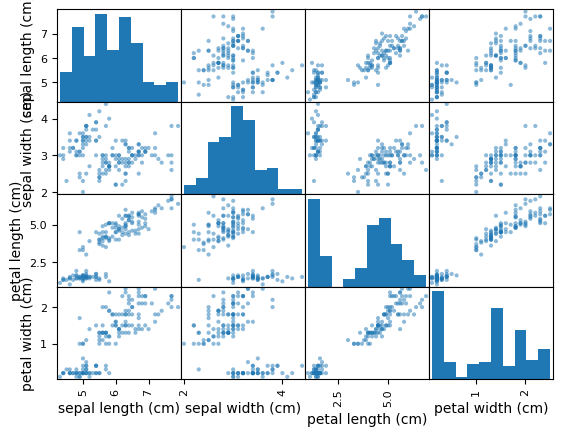

In [9]:
from pandas.plotting import scatter_matrix
scatter_matrix(df)
plt.show()

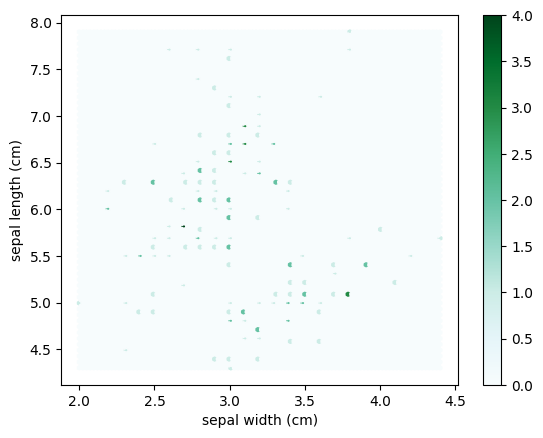

In [10]:
df.plot(kind='hexbin', x='sepal width (cm)', y='sepal length (cm)')
plt.show()

In [15]:
print(df['sepal width (cm)'].corr(df['sepal length (cm)']))
print(df['sepal width (cm)'].corr(df['sepal length (cm)'],method='pearson'))
print(df['sepal width (cm)'].corr(df['sepal length (cm)'],method='spearman'))
print(df['sepal width (cm)'].corr(df['sepal length (cm)'],method='kendall'))

-0.11756978413300198
-0.11756978413300198
-0.166777658283235
-0.0769967881165167
